In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#Data Loading

In [5]:
df=pd.read_csv('Bank_Churn.csv')
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.isnull().sum()

,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


#Data Exoloration

In [8]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
df.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

In [10]:
df.describe(include='O')

,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


In [11]:
df.duplicated().sum()

np.int64(0)

In [23]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [24]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [25]:
df['HasCrCard'].value_counts()

,count
HasCrCard,
1,7055
0,2945


In [26]:
df.groupby('HasCrCard')['Gender'].value_counts()

HasCrCard  Gender
0          Male      1594
           Female    1351
1          Male      3863
           Female    3192
Name: count, dtype: int64

In [27]:
df.groupby('IsActiveMember')['HasCrCard'].value_counts()

IsActiveMember  HasCrCard
0               1            3448
                0            1401
1               1            3607
                0            1544
Name: count, dtype: int64

[Text(0, 0, '4543'), Text(0, 0, '5457')]

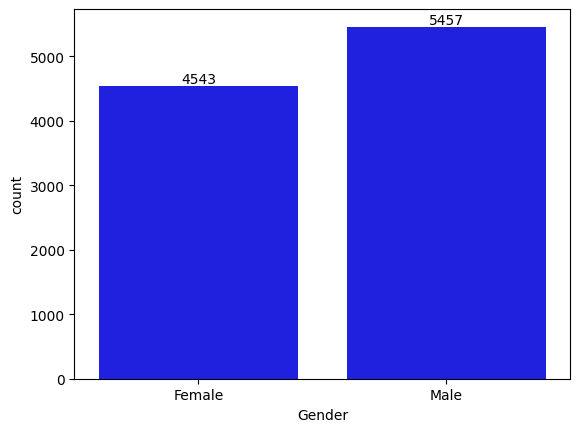

In [28]:
ax=sns.countplot(x=df['Gender'],color='blue')
ax.bar_label(ax.containers[0])

***Question : 1. What is the overall churn rate, and is the dataset imbalanced?***


In [12]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


/tmp/ipykernel_1871/3032179938.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x=df['Exited'],palette='rocket')


[Text(0, 0, '7963')]

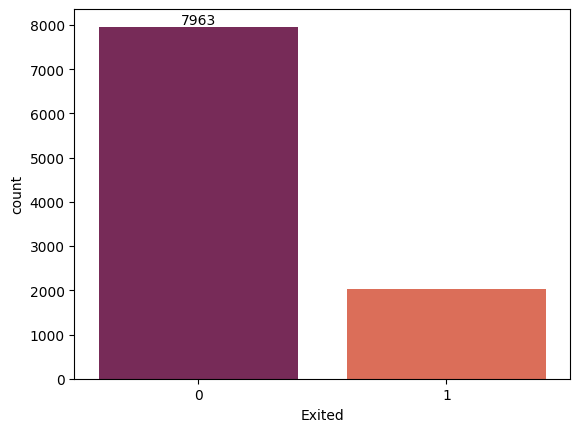

In [22]:
ax=sns.countplot(x=df['Exited'],palette='rocket')
ax.bar_label(ax.containers[0])

**Interpretation** :The dataset shows a churn rate of ~20%, indicating a moderate class imbalance where non-churned customers dominate. This imbalance should be considered during modeling, as models may become biased toward predicting non-churn.

Question 2 : How does account balance relate to churn?
Do customers with zero balance churn more? Or is it the high-balance customers walking away?

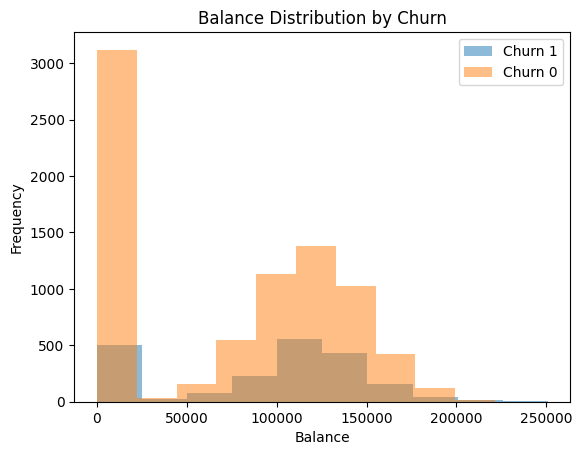

In [30]:
import matplotlib.pyplot as plt

for churn_value in df['Exited'].unique():
    subset = df[df['Exited'] == churn_value]
    plt.hist(subset['Balance'], alpha=0.5, label=f'Churn {churn_value}')

plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.title('Balance Distribution by Churn')
plt.legend()
plt.show()

***Interpretation:*** Lower Balance Customrs contributes highest to Non - Churners and Customrs Having 100k to 150K shows significant Churn rates.

***Question: 3  What is the age distribution of churned vs. retained customers?
Age tends to be a strong predictor in churn models. Is there a "danger zone" age range?***

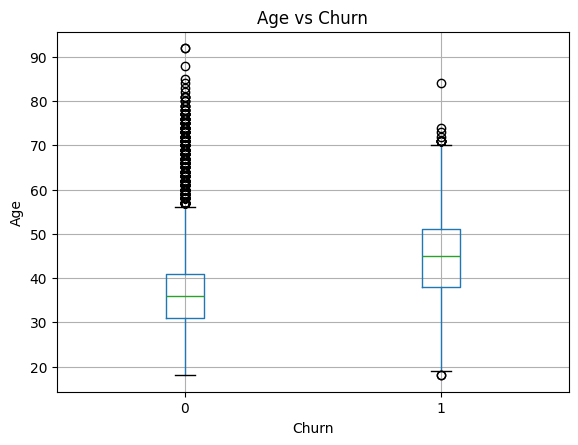

In [31]:
df.boxplot(column='Age', by='Exited')
plt.title('Age vs Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Age')
plt.show()

***Interpretation :*** From the box plot , its visible that Customer from age group 36-52 years old have higher churns and customer from 31 to 40 have lower churns.

***Question 4: Do customers with higher credit scores churn less?
Intuitively, creditworthiness might correlate with loyalty. Does the data agree?***

Credit_Bin
(349.5, 450.0]     189
(450.0, 550.0]    1432
(550.0, 650.0]    3316
(650.0, 750.0]    3465
(750.0, 850.0]    1598
Name: Exited, dtype: int64


/tmp/ipykernel_1871/1478045290.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = df.groupby('Credit_Bin')['Exited'].count()


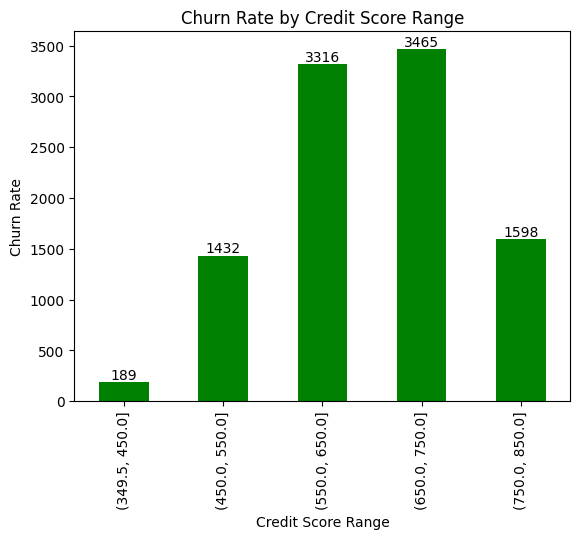

In [32]:
df['Credit_Bin'] = pd.cut(df['CreditScore'], bins=5)

churn_rate = df.groupby('Credit_Bin')['Exited'].count()
print(churn_rate)

ax=churn_rate.plot(kind='bar',color='green')
ax.bar_label(ax.containers[0])
plt.title('Churn Rate by Credit Score Range')
plt.xlabel('Credit Score Range')
plt.ylabel('Churn Rate')
plt.show()

***Interpretation :*** Customers having Higher Range in credit score from 550 to 750 are more likely to churn while customers having the lowest credit score are rarely to churn.

***Question :5 How does churn vary across geographies (France, Germany, Spain)? Is one country disproportionately churning?***

  Geography    Exited
0    France  0.161548
1   Germany  0.324432
2     Spain  0.166734


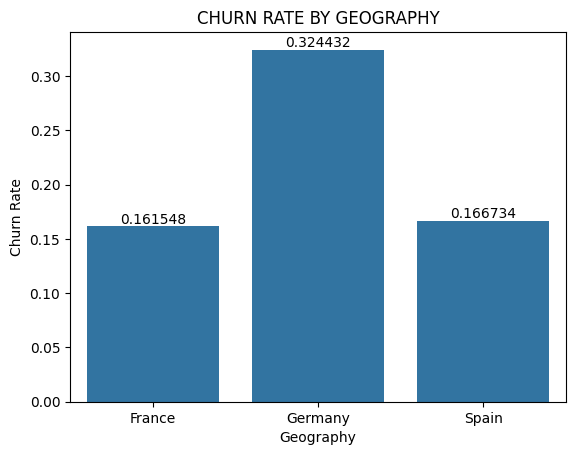

In [33]:
churn_rate=df.groupby('Geography')['Exited'].mean().reset_index()
print(churn_rate)
plt.figure()
ax=sns.barplot(data=churn_rate,x='Geography',y='Exited')
ax.bar_label(ax.containers[0])
plt.title('CHURN RATE BY GEOGRAPHY')
plt.xlabel('Geography')
plt.ylabel('Churn Rate')
plt.show()

**Interpretation** : Germany has the highest rate of churn,twice of what France and Spain have.

***Question 6: Does gender influence churn?***



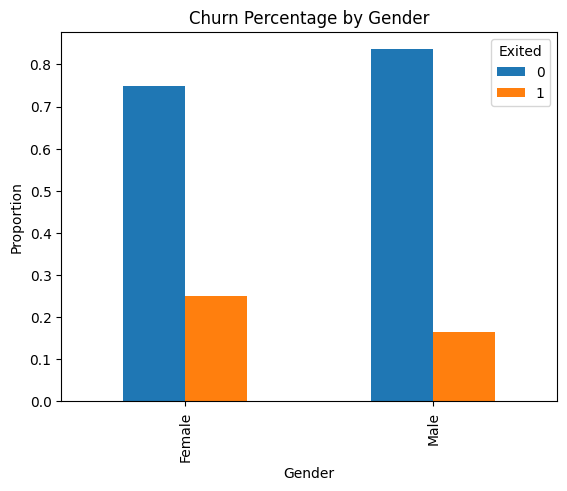

In [35]:

cross_tab = pd.crosstab(df['Gender'], df['Exited'], normalize='index')
cross_tab.plot(kind='bar')

plt.title('Churn Percentage by Gender')
plt.xlabel('Gender')
plt.ylabel('Proportion')

plt.show()

***Interpretation :*** Female customers show a higher churn rate compared to male customers, suggesting potential differences in satisfaction or service expectations.

***Question 7: Does being an active member protect against churn?***



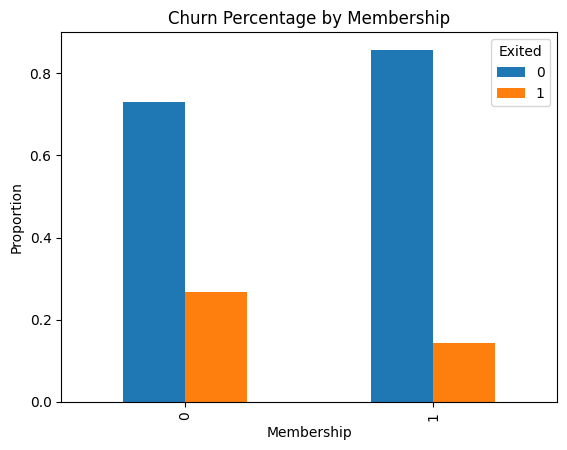

In [39]:
cross_tab = pd.crosstab(df['IsActiveMember'], df['Exited'], normalize='index')

cross_tab.plot(kind='bar')

plt.title('Churn Percentage by Membership')
plt.xlabel('Membership')
plt.ylabel('Proportion')

plt.show()

***Interpretation:*** Customers possesing a Membership tends to stay with the Bank while the non-member customers are more prone to exit.This shows that membership provides satisfactory benefits to the customers making them stay.

***Question 8:Is tenure (years with the bank) a protective factor against churn?
Do newer customers churn more? Or does loyalty plateau after a certain point?***

/tmp/ipykernel_1871/2944527335.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_rate, x='Tenure', y='Exited',palette='viridis')


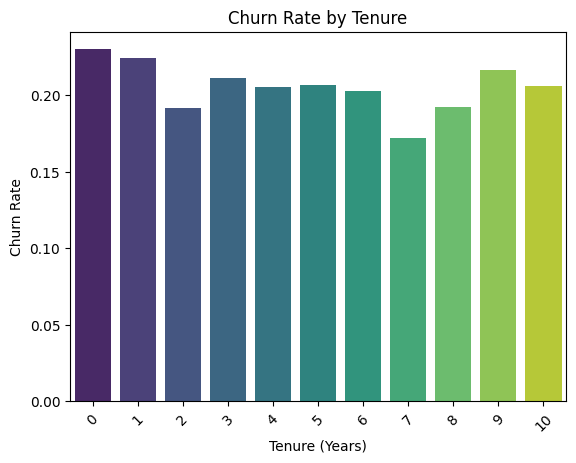

In [37]:
churn_rate = df.groupby('Tenure')['Exited'].mean().reset_index()
# churn_rate['Tenure_Bin'] = churn_rate['Tenure'].astype(str)

plt.figure()
sns.barplot(data=churn_rate, x='Tenure', y='Exited',palette='viridis')

plt.xticks(rotation=45)
plt.xlabel('Tenure (Years)')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Tenure')

plt.show()

***Interpretation :*** Factors like activity status, number of products, or geography likely play a more significant role than tenure.




***Question 9: Does the number of products a customer holds affect churn?***

/tmp/ipykernel_1871/2628652694.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_rate, x='NumOfProducts', y='Exited',palette='rocket')


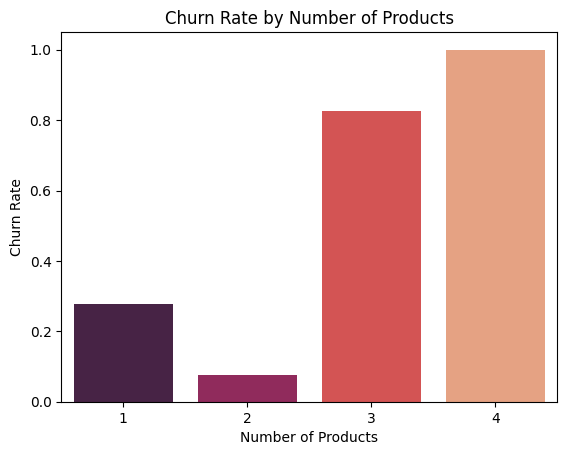

In [38]:
churn_rate = df.groupby('NumOfProducts')['Exited'].mean().reset_index()

plt.figure()
sns.barplot(data=churn_rate, x='NumOfProducts', y='Exited',palette='rocket')

plt.xlabel('Number of Products')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Number of Products')

plt.show()

***Interpretation:*** More products may be overwhelming customers → leads to dissatisfaction.

#Conclusion:

From the analysis, it’s clear that churn is driven more by how customers interact with the bank than by how long they’ve been with it. Customers who are actively engaged are far less likely to leave, making engagement a key factor in retention. At the same time, certain groups — such as customers from specific regions (like Germany), those with mid-range credit scores, and particular balance ranges — show higher chances of churning, indicating areas where the bank may need to focus more attention. Interestingly, having more products doesn’t always reduce churn, suggesting that too much complexity might actually push some customers away. Overall, the findings highlight that improving customer experience, increasing engagement, and targeting high-risk segments can play a crucial role in reducing churn.




***What does a "high-risk" customer look like?***

High-risk customers are typically inactive users from high-churn regions, with mid-range credit scores, higher balances, and suboptimal product engagement, indicating that lack of engagement and unmet expectations are key drivers of churn.